In [2]:
import torch as pt

mols_test = pt.load('./data/mine/test_11499.pt')
print(len(mols_test))
mols_all = pt.load('./data/mine/mols_all.pt')
print(len(mols_all))
extra10 = pt.load('./data/mine/extra10.pt')
print(len(extra10))

/tmp/ipykernel_2954611/935446440.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mols_test = pt.load('./data/mine/test_11499.pt')


11499


/tmp/ipykernel_2954611/935446440.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mols_all = pt.load('./data/mine/mols_all.pt')


2253216
10


/tmp/ipykernel_2954611/935446440.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  extra10 = pt.load('./data/mine/extra10.pt')


In [ ]:
from copy import deepcopy
import numpy as np


extra10_sqrt = deepcopy(extra10)
for spectrum in extra10_sqrt:
    intensities = spectrum.intensities
    intensities = np.sqrt(intensities)
    spectrum._peaks._intensities = intensities

[0.16186414 0.0969536  0.04123106 0.23388031 0.08888194 0.38288379
 0.07071068 0.03741657 0.083666   0.0678233  0.19924859 0.08544004
 0.12806248 0.04358899 0.06164414 0.1        0.0591608  0.06480741
 0.07615773 0.04242641 0.05       0.03464102 0.04472136 0.12041595
 0.09899495 0.08062258 0.09433981 0.03605551 0.09539392 0.06082763
 0.09591663 0.05830952 0.03872983 0.16970563 1.         0.26944387
 0.08246211 0.15937377 0.04795832 0.04358899 0.04       0.04690416
 0.03872983 0.3792097  0.13747727 0.04358899 0.07483315 0.41255303
 0.1805547  0.06164414]


In [ ]:
extra_pre = mols_all[2146690:2146700]
print(extra_pre[0].intensities)
extra_pre_sqrt = deepcopy(extra_pre)
for spectrum in extra_pre_sqrt:
    intensities = spectrum.intensities
    intensities = np.sqrt(intensities)
    spectrum._peaks._intensities = intensities

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from typing import Optional, Union
import numpy as np

_annotation_kws = {
    "horizontalalignment": "left",  # if not mirror_intensity else "right",
    "verticalalignment": "center",
    "fontsize": 7,
    "rotation": 90,
    "rotation_mode": "anchor",
    "zorder": 5,
}


def plot_spectrum(spectrum,
                  annotate_ions: bool = False,
                  mirror_intensity: bool = False,
                  grid: Union[bool, str] = True,
                  ax: plt.Axes = None,
                  peak_color="teal",
                  min_mz: float = None,
                  max_mz: float = None,
                  **plt_kwargs) -> plt.Axes:
    # pylint: disable=too-many-locals, too-many-arguments
    if ax is None:
        ax = plt.gca()

    if min_mz is None:
        min_mz = max(0, np.floor(spectrum.peaks.mz[0] / 100 - 1) * 100)
    if max_mz is None:
        max_mz = np.ceil(spectrum.peaks.mz[-1] / 100 + 1) * 100
    max_intensity = spectrum.peaks.intensities.max()

    intensities = spectrum.peaks.intensities / max_intensity

    def make_stems():
        """calculate where the stems of the spectrum peaks are going to be"""
        x = np.zeros([2, spectrum.peaks.mz.size], dtype="float")
        y = np.zeros(x.shape)
        x[:, :] = np.tile(spectrum.peaks.mz, (2, 1))
        y[1, :] = intensities
        return x, y

    x, y = make_stems()
    if mirror_intensity is True:
        y = -y
    ax.plot(x, y, color=peak_color, linewidth=1.0, marker="", zorder=5, **plt_kwargs)
    if annotate_ions and isinstance(spectrum.get("peak_comments"), dict):
        for mz, comment in spectrum.get("peak_comments").items():
            idx = (-abs(spectrum.peaks.mz - mz)).argmax()
            ax.text(mz, intensities[idx], f"m/z: {mz} \n {comment}",
                    _annotation_kws)

    ax.set_xlim(min_mz, max_mz)
    # ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    y_max = 1.25 if annotate_ions else 1.10
    ax.set_ylim(*(0, y_max) if not mirror_intensity else (-y_max, 0))
    y_ticks = ax.get_yticks()  
    ax.set_yticks(y_ticks[(y_ticks >= 0) & (y_ticks <= 1.0)])  # 确保y轴刻度在0到1之间

    ax.xaxis.set_minor_locator(mticker.AutoLocator())
    ax.yaxis.set_minor_locator(mticker.AutoLocator())
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    if grid in (True, "both", "major"):
        ax.grid(visible=True, which="major", color="#9E9E9E", linewidth=0.2)
    if grid in (True, "both", "minor"):
        ax.grid(visible=True, which="minor", color="#9E9E9E", linewidth=0.2)
    ax.set_axisbelow(True)

    ax.tick_params(axis="both", which="both", labelsize="small")
    y_ticks = ax.get_yticks()
    ax.set_yticks(y_ticks[y_ticks <= 1.0])

    ax.set_xlabel("m/z", style="italic")
    ax.set_ylabel("Intensity")
    title = "Spectrum" if spectrum.get("compound_name") is None else spectrum.get("compound_name")
    # ax.set_title(title)
    return ax


def plot_spectra_mirror(spec_top,
                        spec_bottom,
                        ax: Optional[plt.Axes] = None,
                        color_top="darkblue",
                        color_bottom="teal",
                        **spectrum_kws) -> plt.Axes:
    if ax is None:
        ax = plt.gca()

    if spectrum_kws is None:
        spectrum_kws = {}

    if 'peak_color' in spectrum_kws:
        raise ValueError("'peak_color' should not be set for `plot_spectra_mirror`. "
                         "Use 'color_top' and 'color_bottom' instead.")

    # Top spectrum.
    plot_spectrum(spec_top, mirror_intensity=False, ax=ax, peak_color=color_top, **spectrum_kws)
    y_max = ax.get_ylim()[1]

    # Mirrored bottom spectrum.
    plot_spectrum(spec_bottom, mirror_intensity=True, ax=ax, peak_color=color_bottom, **spectrum_kws)
    y_min = ax.get_ylim()[0]
    ax.set_ylim(y_min, y_max)

    ax.axhline(0, color="#9E9E9E", zorder=10)

    # Update axes so that both spectra fit.
    min_mz = max(
        [
            0,
            np.floor(spec_top.peaks.mz[0] / 100 - 1) * 100,
            np.floor(spec_bottom.peaks.mz[0] / 100 - 1) * 100,
        ]
    )
    max_mz = max(
        [
            np.ceil(spec_top.peaks.mz[-1] / 100 + 1) * 100,
            np.ceil(spec_bottom.peaks.mz[-1] / 100 + 1) * 100,
        ]
    )

    # # Enforce min_mz and max_mz if provided
    max_mz = spectrum_kws.get("max_mz", max_mz)
    min_mz = spectrum_kws.get("min_mz", min_mz)

    ax.set_xlim(min_mz, max_mz)
    ax.yaxis.set_major_locator(mticker.AutoLocator())
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{abs(x)}")
    )

    name1 = "Experiment_origin" if spec_top.get("compound_name") is None else spec_top.get("compound_name")
    name2 = "Experiment_sqrt" if spec_bottom.get("compound_name") is None else spec_bottom.get("compound_name")

    x_text = 0.04 * (max_mz - min_mz) + min_mz
    ax.text(x_text, y_max, name1, ha="left", va="top", zorder=2, backgroundcolor="white")
    ax.text(x_text, y_min, name2, ha="left", va="bottom", zorder=2, backgroundcolor="white")
    return ax

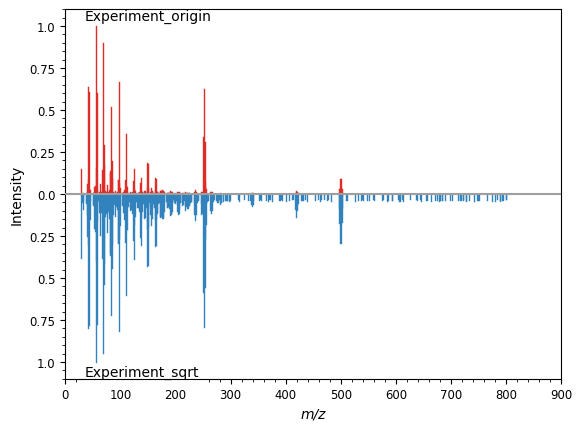

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()
ax = plot_spectra_mirror(extra10_sqrt[9], mols_all[9], ax=ax, grid=False, color_top='#de2d26', color_bottom='#3182bd')
fig.savefig('./picture/extra9_orig_sqrt.svg', format='svg', dpi=500)

In [6]:
from torch.utils.data import DataLoader
from utils.data import SpecDataset, collate_fun_emb

dataset_test = SpecDataset(mols_test)
loader_test = DataLoader(dataset_test, batch_size=2048, shuffle=False,
                        num_workers=8, collate_fn=collate_fun_emb)
dataset_lib = SpecDataset(mols_all)
loader_lib = DataLoader(dataset_lib, batch_size=2048, shuffle=False,
                        num_workers=8, collate_fn=collate_fun_emb)
dataset_extra10 = SpecDataset(extra10)
loader_extra10 = DataLoader(dataset_extra10, batch_size=10, shuffle=False,
                            num_workers=1, collate_fn=collate_fun_emb)

In [7]:
from utils.model import Spec2Emb

gpu=7
model = Spec2Emb().to(gpu)
model.load_state_dict(pt.load('./model/base_peak0.01_epoch4.pth', map_location='cpu'))

/tmp/ipykernel_2954611/1305591878.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(pt.load('./model/base_peak0.01_epoch4.pth', map_location='cpu'))


<All keys matched successfully>

In [8]:
from utils.tools import gen_embeddings, build_idx

embs_lib_05 = gen_embeddings(model, loader_lib, gpu, power=0.5)
embs_extra_05 = gen_embeddings(model, loader_extra10, gpu, power=0.5)
I_05, Dis_05 = build_idx(embs_lib_05, embs_extra_05, gpu) # (10, 200)

embs_lib_1 = gen_embeddings(model, loader_lib, gpu, power=1.0)
embs_extra_1 = gen_embeddings(model, loader_extra10, gpu, power=1.0)
I_1, Dis_1 = build_idx(embs_lib_1, embs_extra_1, gpu)

Searching time:  0:00:00.028359
Searching time:  0:00:00.016185


In [9]:
for i in range(len(I_1)):
    print('compound:'+str(i+1))
    for j in range(len(I_1[i])):
        if mols_all[I_1[i][j]].metadata['inchikey'] == extra10[i].metadata['inchikey']:
            print('Rank:', j+1)
            break

compound:1
Rank: 113
compound:2
Rank: 1
compound:3
Rank: 3
compound:4
Rank: 3
compound:5
Rank: 1
compound:6
Rank: 2
compound:7
Rank: 19
compound:8
compound:9
Rank: 77
compound:10


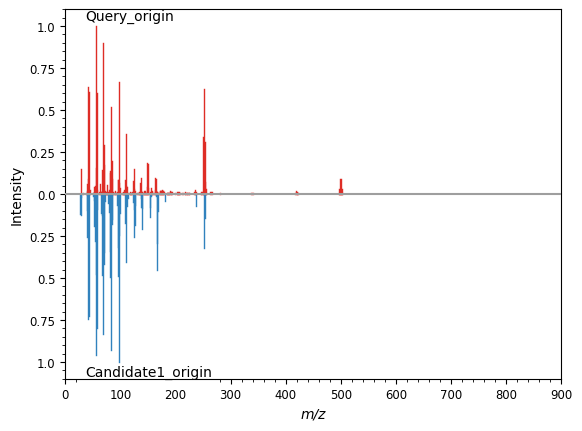

In [ ]:
def plot_spectra_mirror(spec_top,
                        spec_bottom,
                        ax: Optional[plt.Axes] = None,
                        color_top="darkblue",
                        color_bottom="teal",
                        **spectrum_kws) -> plt.Axes:
    if ax is None:
        ax = plt.gca()

    if spectrum_kws is None:
        spectrum_kws = {}

    if 'peak_color' in spectrum_kws:
        raise ValueError("'peak_color' should not be set for `plot_spectra_mirror`. "
                         "Use 'color_top' and 'color_bottom' instead.")

    # Top spectrum.
    plot_spectrum(spec_top, mirror_intensity=False, ax=ax, peak_color=color_top, **spectrum_kws)
    y_max = ax.get_ylim()[1]

    # Mirrored bottom spectrum.
    plot_spectrum(spec_bottom, mirror_intensity=True, ax=ax, peak_color=color_bottom, **spectrum_kws)
    y_min = ax.get_ylim()[0]
    ax.set_ylim(y_min, y_max)

    ax.axhline(0, color="#9E9E9E", zorder=10)

    # Update axes so that both spectra fit.
    min_mz = max(
        [
            0,
            np.floor(spec_top.peaks.mz[0] / 100 - 1) * 100,
            np.floor(spec_bottom.peaks.mz[0] / 100 - 1) * 100,
        ]
    )
    max_mz = max(
        [
            np.ceil(spec_top.peaks.mz[-1] / 100 + 1) * 100,
            np.ceil(spec_bottom.peaks.mz[-1] / 100 + 1) * 100,
        ]
    )

    # # Enforce min_mz and max_mz if provided
    max_mz = spectrum_kws.get("max_mz", max_mz)
    min_mz = spectrum_kws.get("min_mz", min_mz)

    ax.set_xlim(min_mz, max_mz)
    ax.yaxis.set_major_locator(mticker.AutoLocator())
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{abs(x)}")
    )

    name1 = "Query_origin" if spec_top.get("compound_name") is None else spec_top.get("compound_name")
    name2 = "Candidate1_origin" if spec_bottom.get("compound_name") is None else spec_bottom.get("compound_name")

    x_text = 0.04 * (max_mz - min_mz) + min_mz
    ax.text(x_text, y_max, name1, ha="left", va="top", zorder=2, backgroundcolor="white")
    ax.text(x_text, y_min, name2, ha="left", va="bottom", zorder=2, backgroundcolor="white")
    return ax

fig = plt.figure()
ax = fig.add_subplot()
ax = plot_spectra_mirror(extra10[9], mols_all[I_1[9][0]], ax=ax, grid=False, color_top='#de2d26', color_bottom='#3182bd')
fig.savefig('./picture/extra9_orig_query_candidate1.svg', format='svg', dpi=500)

In [10]:
for i in range(len(I_05)):
    print('compound:'+str(i+1))
    for j in range(len(I_05[i])):
        if mols_all[I_05[i][j]].metadata['inchikey'] == extra10[i].metadata['inchikey']:
            print('Rank:', j+1)
            break

compound:1
Rank: 2
compound:2
Rank: 1
compound:3
Rank: 1
compound:4
Rank: 1
compound:5
Rank: 1
compound:6
Rank: 2
compound:7
Rank: 2
compound:8
Rank: 21
compound:9
compound:10


In [ ]:
sqrt_candidates = [mols_all[I_05[i][0]] for i in range(10)]
print(sqrt_candidates[0].intensities)
for spec in sqrt_candidates:
    intensities = spec.intensities
    intensities = np.sqrt(intensities)
    spec._peaks._intensities = intensities

[0.05005 0.18919 0.07508 0.24224 0.1011  0.06206 0.01401 0.01101 0.02803
 0.21021 0.04004 0.40841 0.03504 0.01201 0.04304 0.06006 0.69469 0.10911
 0.12412 1.      0.3003  0.11211 0.10511 0.02703 0.6036  0.22122 0.13614
 0.03303]
[0.22371857 0.43495977 0.2740073  0.49217883 0.31796226 0.24911845
 0.11836385 0.10492855 0.16742162 0.45848664 0.20009998 0.63906964
 0.18718974 0.10959015 0.20746084 0.24507142 0.83348065 0.33031803
 0.35230668 1.         0.54799635 0.33482831 0.32420672 0.16440803
 0.77691698 0.4703403  0.36897154 0.18174157]


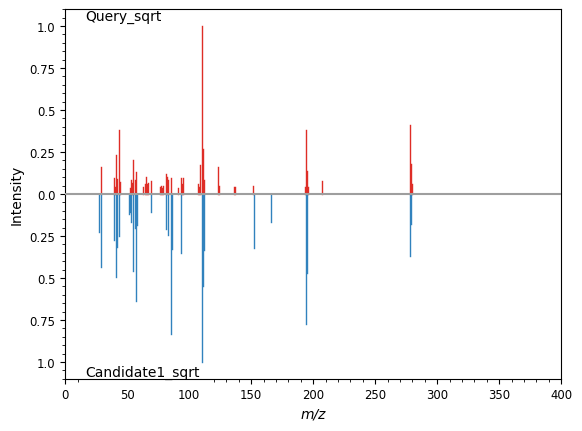

In [46]:
def plot_spectra_mirror(spec_top,
                        spec_bottom,
                        ax: Optional[plt.Axes] = None,
                        color_top="darkblue",
                        color_bottom="teal",
                        **spectrum_kws) -> plt.Axes:
    if ax is None:
        ax = plt.gca()

    if spectrum_kws is None:
        spectrum_kws = {}

    if 'peak_color' in spectrum_kws:
        raise ValueError("'peak_color' should not be set for `plot_spectra_mirror`. "
                         "Use 'color_top' and 'color_bottom' instead.")

    # Top spectrum.
    plot_spectrum(spec_top, mirror_intensity=False, ax=ax, peak_color=color_top, **spectrum_kws)
    y_max = ax.get_ylim()[1]

    # Mirrored bottom spectrum.
    plot_spectrum(spec_bottom, mirror_intensity=True, ax=ax, peak_color=color_bottom, **spectrum_kws)
    y_min = ax.get_ylim()[0]
    ax.set_ylim(y_min, y_max)

    ax.axhline(0, color="#9E9E9E", zorder=10)

    # Update axes so that both spectra fit.
    min_mz = max(
        [
            0,
            np.floor(spec_top.peaks.mz[0] / 100 - 1) * 100,
            np.floor(spec_bottom.peaks.mz[0] / 100 - 1) * 100,
        ]
    )
    max_mz = max(
        [
            np.ceil(spec_top.peaks.mz[-1] / 100 + 1) * 100,
            np.ceil(spec_bottom.peaks.mz[-1] / 100 + 1) * 100,
        ]
    )

    # # Enforce min_mz and max_mz if provided
    max_mz = spectrum_kws.get("max_mz", max_mz)
    min_mz = spectrum_kws.get("min_mz", min_mz)

    ax.set_xlim(min_mz, max_mz)
    ax.yaxis.set_major_locator(mticker.AutoLocator())
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{abs(x)}")
    )

    name1 = "Query_sqrt" if spec_top.get("compound_name") is None else spec_top.get("compound_name")
    name2 = "Candidate1_sqrt" if spec_bottom.get("compound_name") is None else spec_bottom.get("compound_name")

    x_text = 0.04 * (max_mz - min_mz) + min_mz
    ax.text(x_text, y_max, name1, ha="left", va="top", zorder=2, backgroundcolor="white")
    ax.text(x_text, y_min, name2, ha="left", va="bottom", zorder=2, backgroundcolor="white")
    return ax

fig = plt.figure()
ax = fig.add_subplot()
ax = plot_spectra_mirror(extra10_sqrt[0], mols_all[I_05[0][0]], ax=ax, grid=False, color_top='#de2d26', color_bottom='#3182bd')
fig.savefig('./picture/extra0_sqrt_query_candidate1.svg', format='svg', dpi=500)

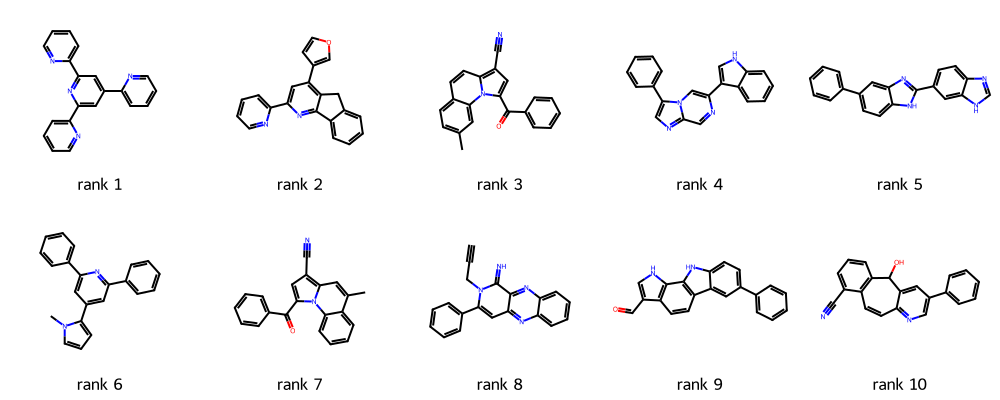

In [9]:
from rdkit import Chem
from rdkit.Chem import Draw

candidate_mols9 = [mols_all[I_10[8][i]] for i in range(10)]
candidate_smi9 = [mol.metadata['smiles'] for mol in candidate_mols9]
Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in candidate_smi9], molsPerRow=5, subImgSize=(200, 200), 
                     legends=[f'rank {i}' for i in range(1,11,1)], useSVG=True)